In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner
from ipywidgets import *

Numba not installed, using numpy instead


In [2]:
h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']
nh3_xsec = OpacityCache()['NH3']
o2_xsec = OpacityCache()['O2']
so2_xsec = OpacityCache()['SO2']

In [ ]:
%matplotlib widget

fig = figure(figsize=(8, 4), dpi=100)
frame = fig.add_subplot(1, 1, 1)

wavenumber = h2o_xsec.wavenumberGrid
frame.set_xlim(0.3, 8) #cover Ariel wavelength range
frame.set_xlabel("Wavelength (microns)")
frame.set_ylabel("Opacity (cm^2/molecule)")

xsec, = frame.plot(1e4/wavenumber, h2o_xsec.opacity(1500, 1.0*1e5)) #micron, cm^2/molecule | Kelvin, Pa

def update_cross(temperature=1500.0, pressure_bar=1.0):
    pressure_pa = pressure_bar * 1e5  # convert bar to Pa
    xsec.set_ydata(h2o_xsec.opacity(temperature, pressure_pa))
    frame.relim()
    frame.autoscale_view()
    fig.canvas.draw()

interact(update_cross, temperature=(300.0, 4000.0, 50), pressure_bar=(0.001, 3000.0, 1));

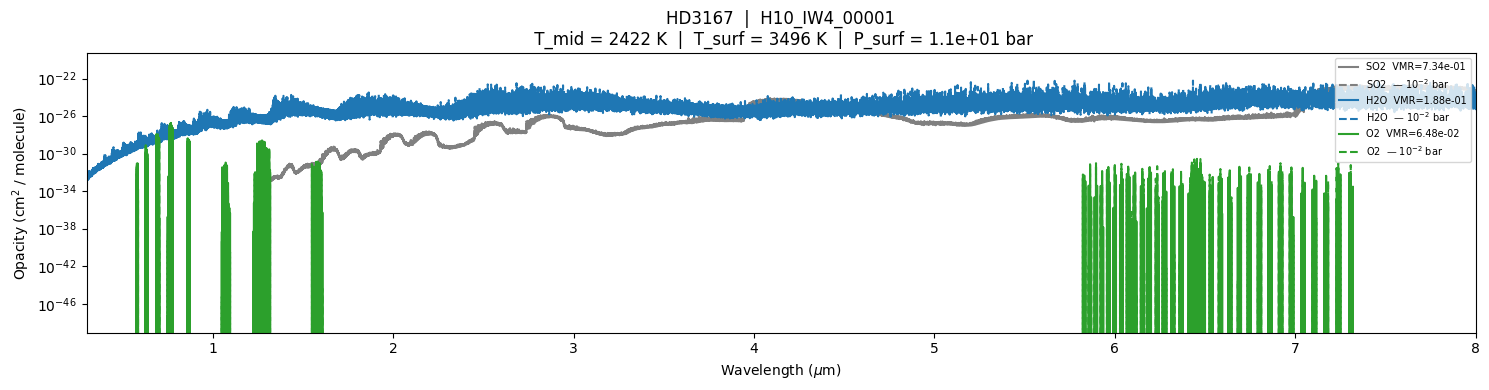

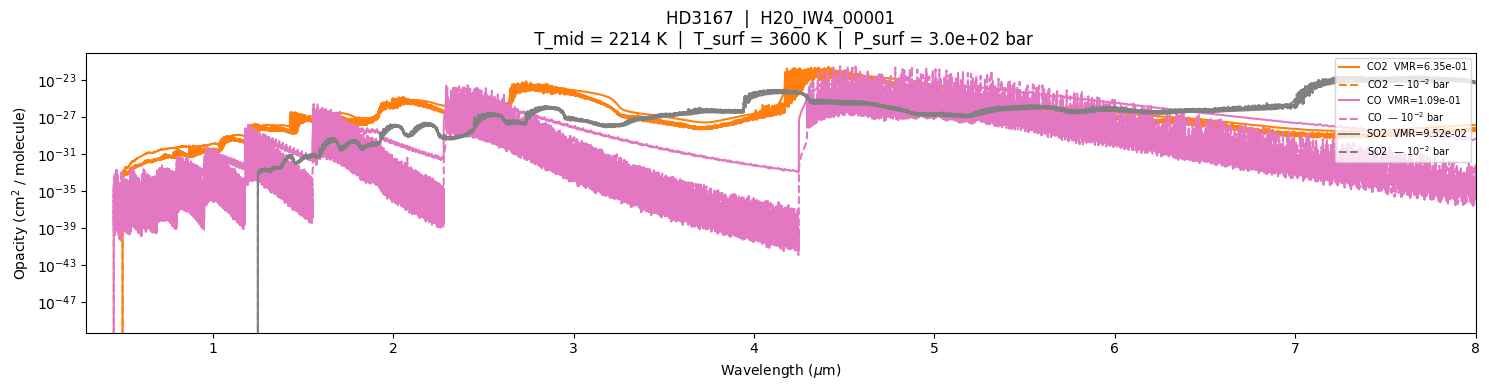

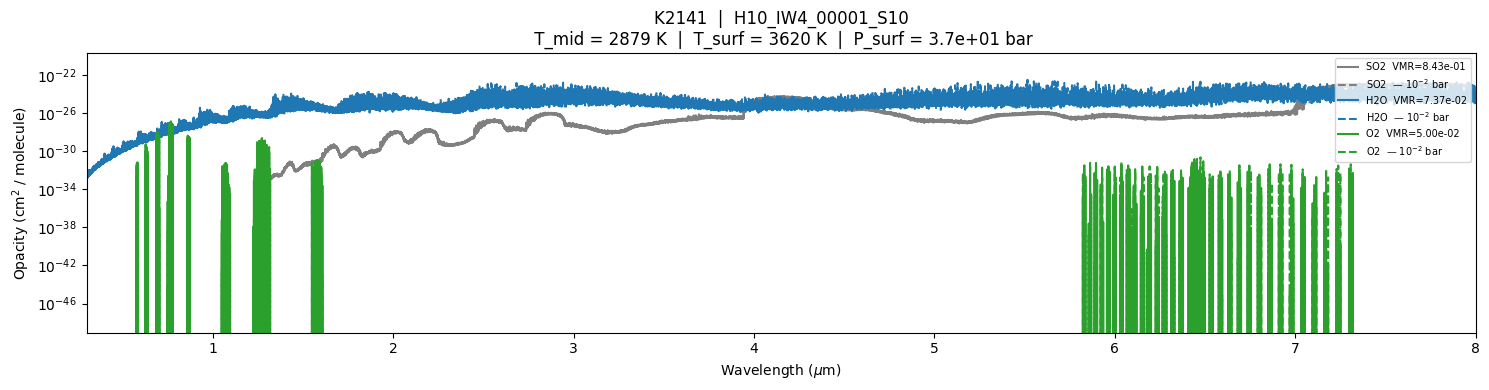

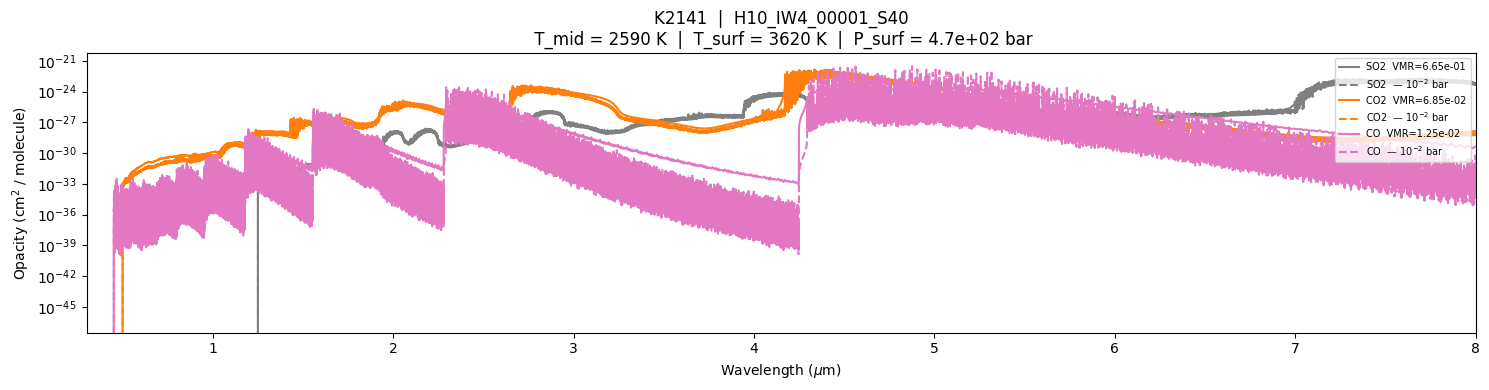

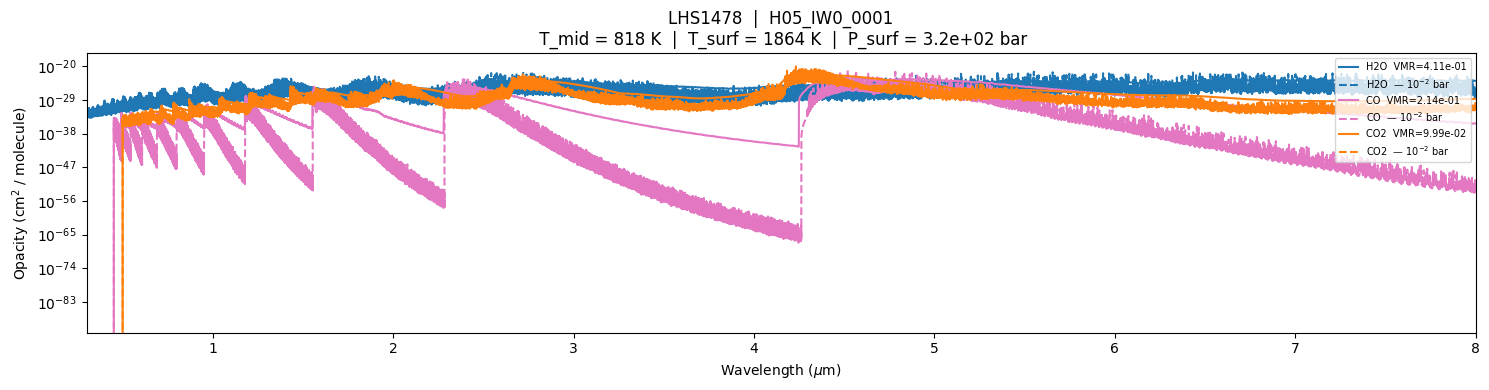

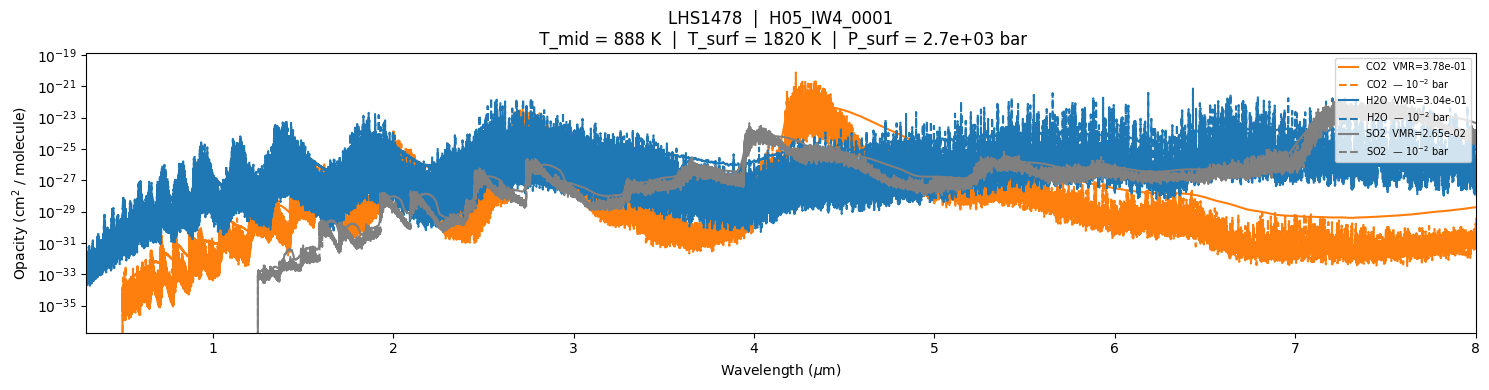

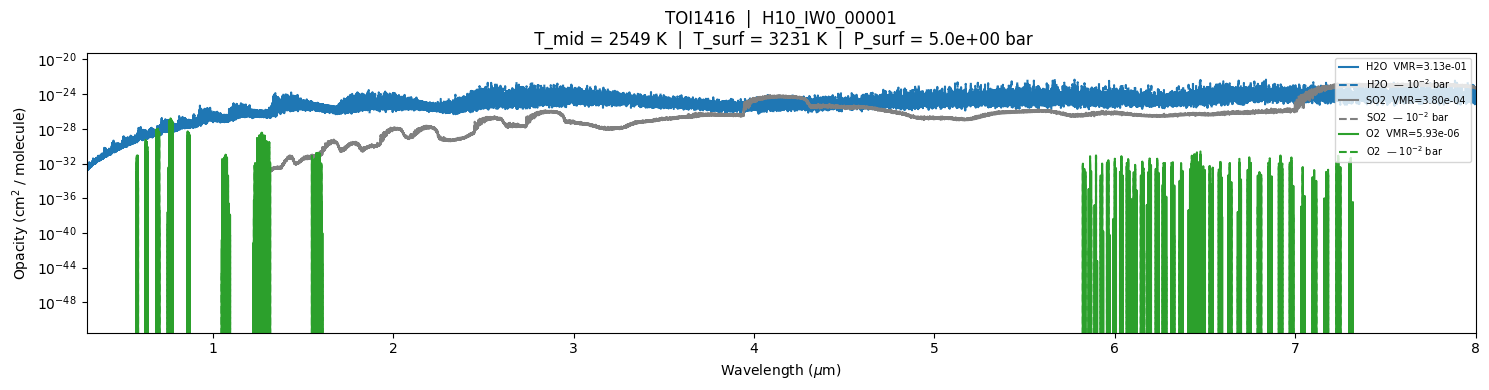

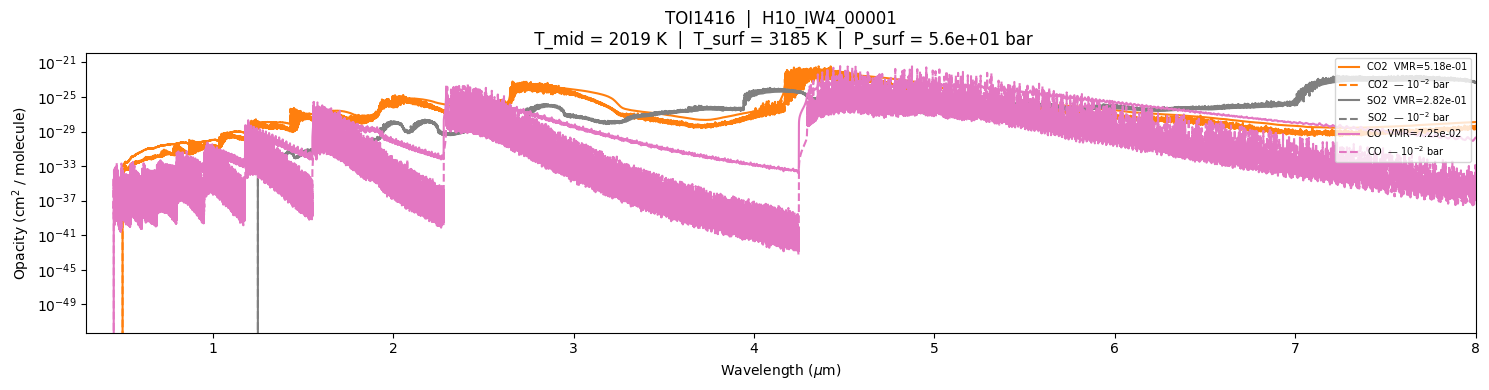

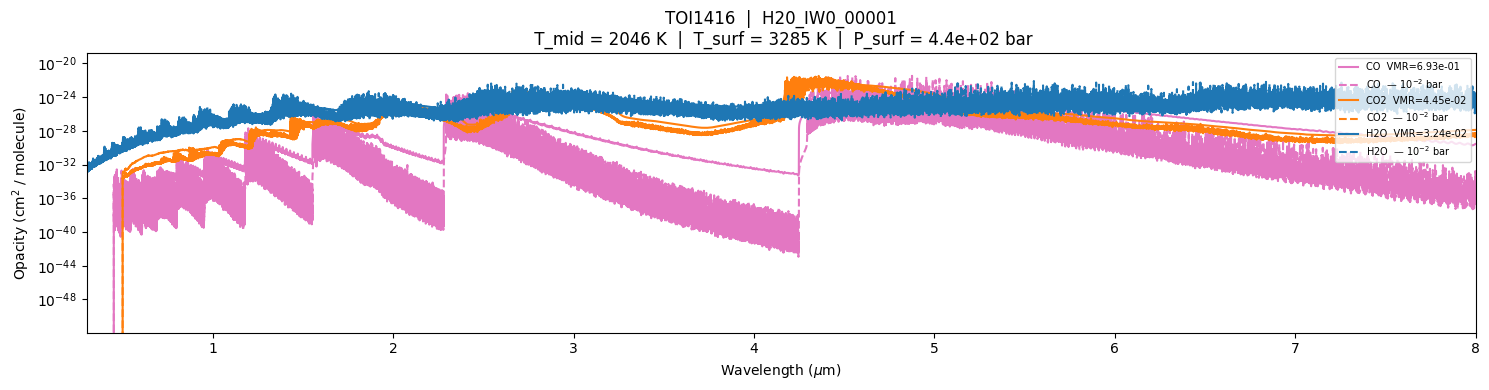

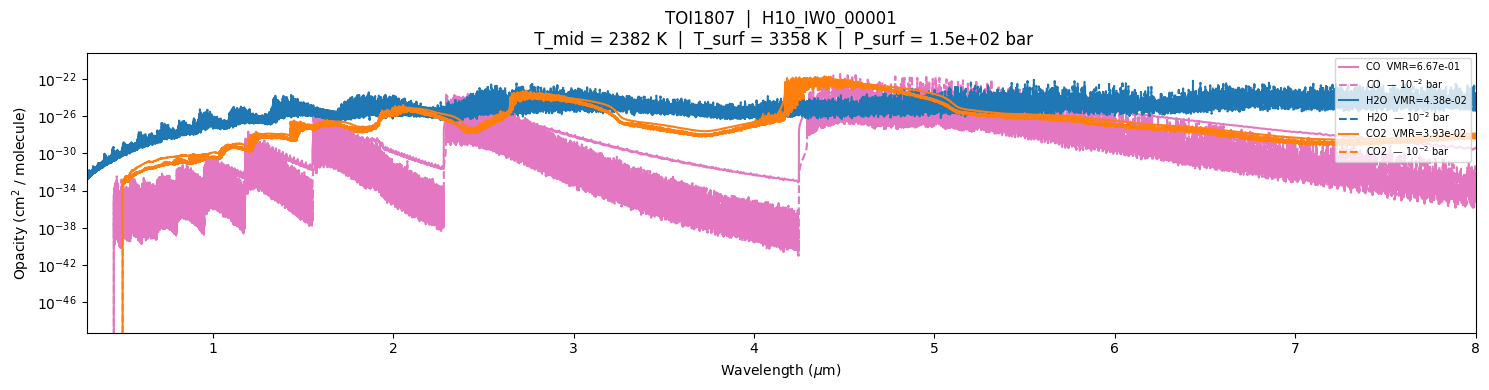

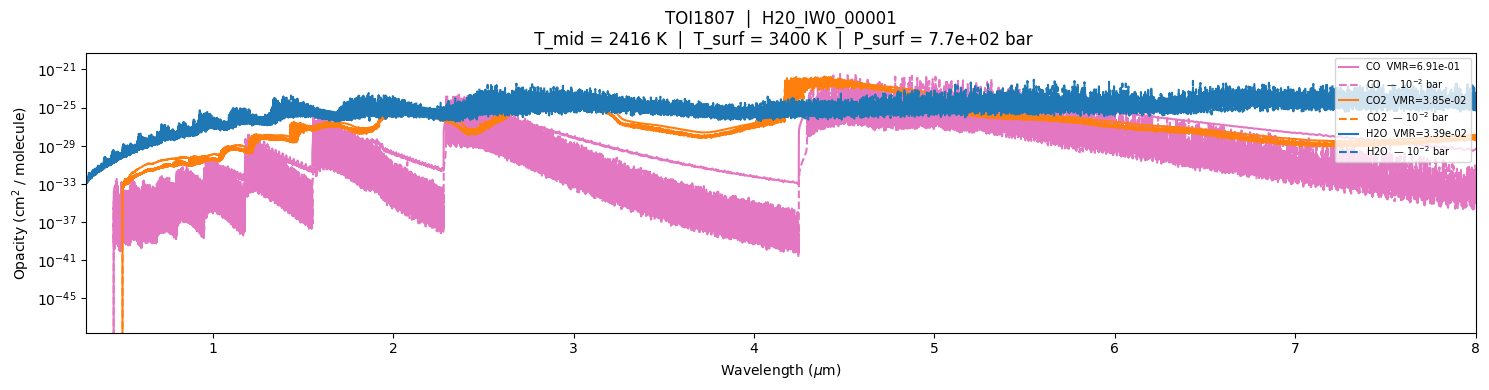

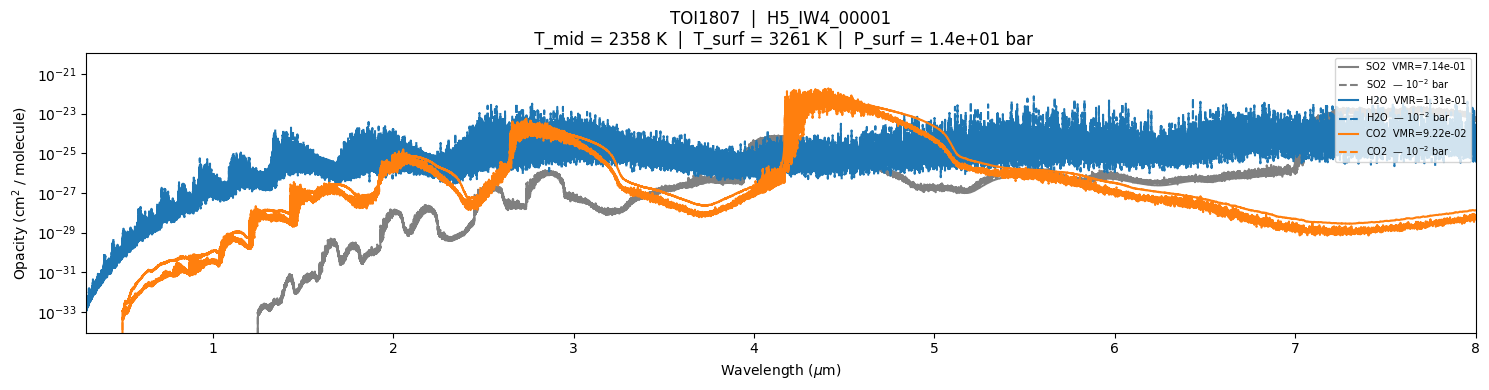

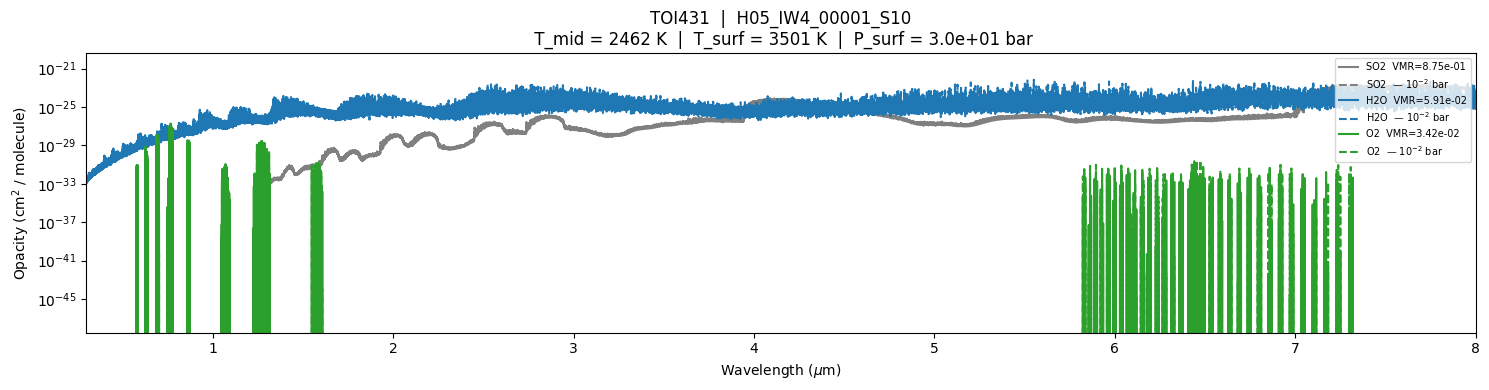

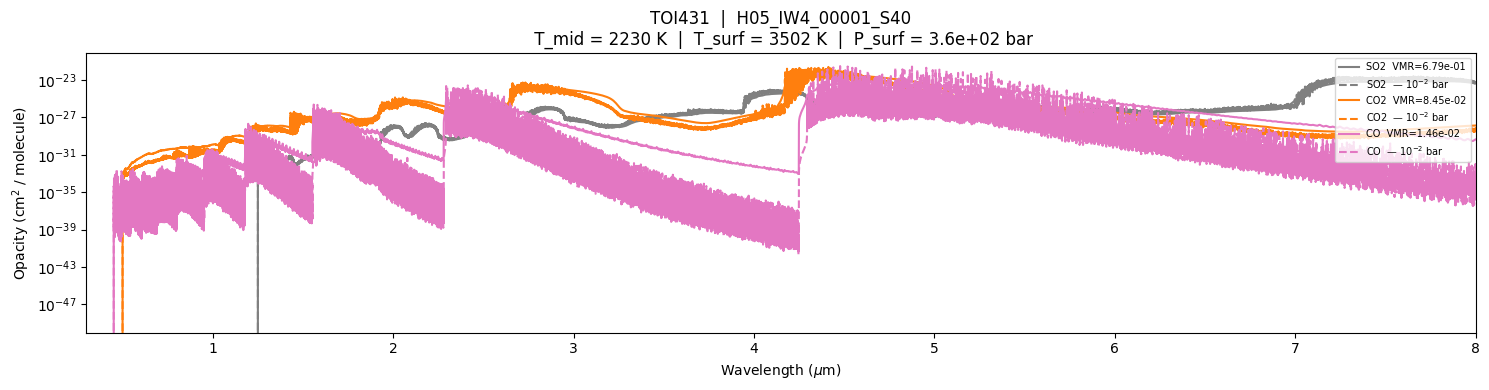

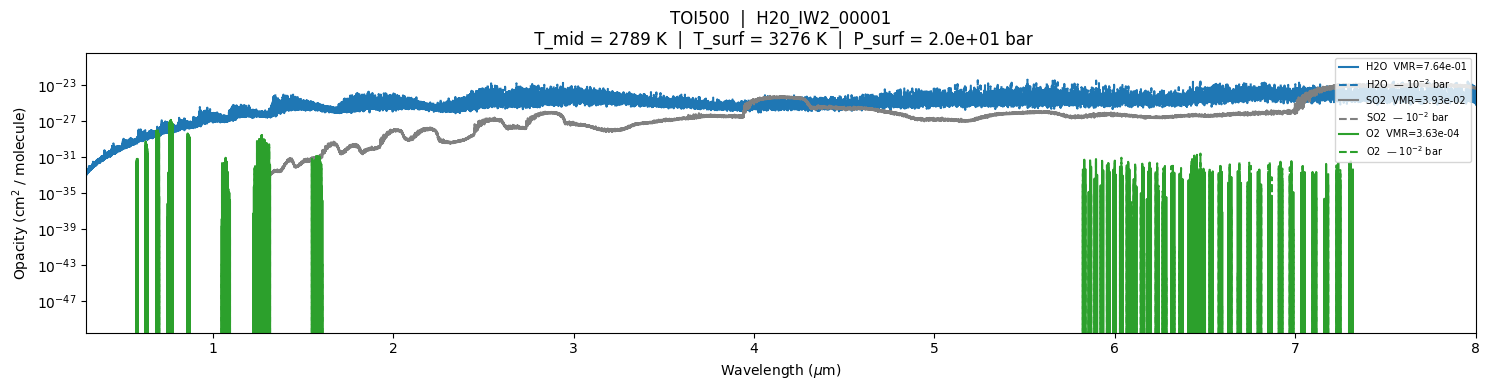

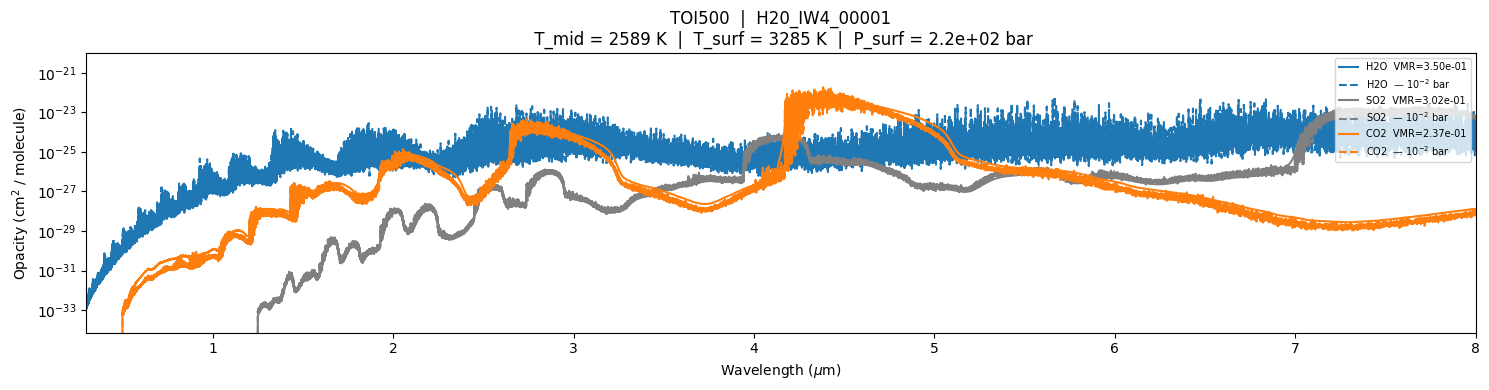

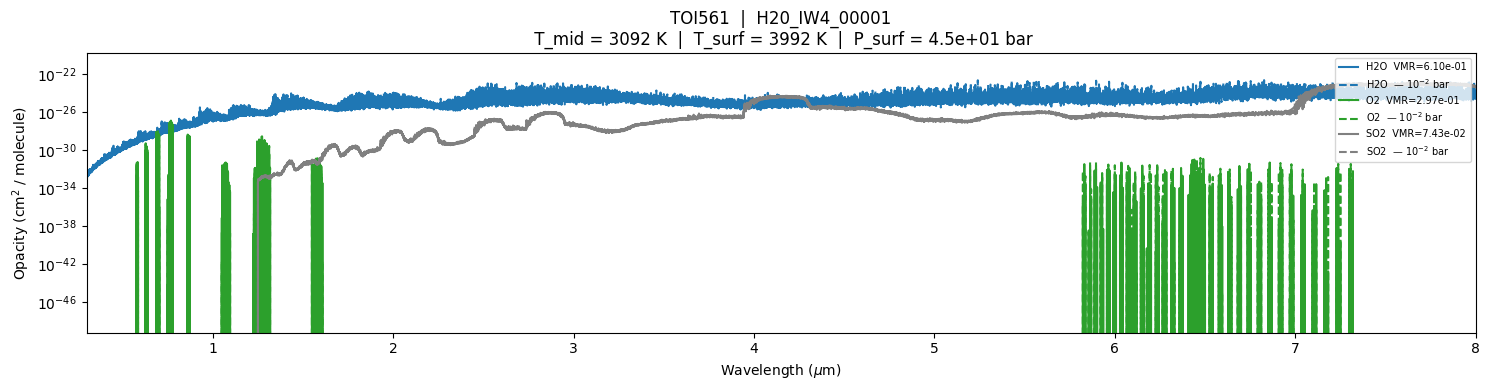

In [4]:
import glob

# Map molecule names to loaded xsec objects (only those with available cross-section data)
mol_to_xsec = {
    'H2O':  h2o_xsec,
    'CH4':  ch4_xsec,
    'CO2':  co2_xsec,
    'CO':   co_xsec,
    'NH3':  nh3_xsec,
    'O2':   o2_xsec,
    'SO2':  so2_xsec,
}

wavenumber_grid = h2o_xsec.wavenumberGrid
wavelength_um = 1e4 / wavenumber_grid  # microns

MOL_COLORS = {
    'H2O': 'tab:blue',
    'CO2': 'tab:orange',
    'O2':  'tab:green',
    'SO2': 'gray',
    'CO':  'tab:pink',
    'CH4': 'tab:red',
    'NH3': 'tab:purple',
}
tp_files = sorted(glob.glob('PLANETS/*/*_TP.csv'))

for tp_file in tp_files:
    parts = tp_file.replace('\\', '/').split('/')
    planet_name = parts[1]
    sim_name    = parts[2].replace('_TP.csv', '')

    # --- Read TP profile ---
    tp_data         = pd.read_csv(tp_file)
    pressure_pa     = tp_data['Pressure (Pa)'].values          # Pa, descending (surface first)
    temp_substellar = tp_data['Substellar Temperature (K)'].values

    # Surface conditions (highest pressure = first row)
    surf_p_pa = pressure_pa[0]
    surf_t    = temp_substellar[0]

    # Conditions at 10^-2 bar (= 1000 Pa)
    target_p_pa = 1e-2 * 1e5
    idx_mid     = np.argmin(np.abs(pressure_pa - target_p_pa))
    mid_t       = temp_substellar[idx_mid]

    # ---- Read chemistry from runtime_helpfile ----
    helpfile_path = f'PLANETS/{planet_name}/{sim_name}/runtime_helpfile.csv'
    if not os.path.exists(helpfile_path):
        print(f'[skip] No runtime_helpfile found at {helpfile_path}')
        continue

    helpdata = pd.read_csv(helpfile_path, sep='\t')
    last_row = helpdata.iloc[-1]

    # Collect VMRs for molecules that have cross-section data
    mol_vmrs = {}
    for mol in mol_to_xsec:
        col = f'{mol}_vmr'
        if col in helpdata.columns:
            val = float(last_row[col])
            if val > 0:
                mol_vmrs[mol] = val

    # Pick top molecules by VMR until cumulative sum reaches ~100% (max 3)
    top3 = []
    cumulative_vmr = 0.0
    for mol, vmr in sorted(mol_vmrs.items(), key=lambda x: x[1], reverse=True):
        top3.append((mol, vmr))
        cumulative_vmr += vmr
        if len(top3) >= 3 or cumulative_vmr >= 0.999:
            break

    # ---- Plot 2: Opacity comparison for top-3 molecules ----
    fig2, ax2 = plt.subplots(figsize=(15, 4))
    for mol, vmr in top3:
        color = MOL_COLORS[mol]
        xsec_obj = mol_to_xsec[mol]
        op_surf  = xsec_obj.opacity(float(surf_t), float(surf_p_pa))
        op_mid   = xsec_obj.opacity(float(mid_t),  float(target_p_pa))

        ax2.plot(wavelength_um, op_surf, color=color, ls='-',  lw=1.5,
                 label=f'{mol}  VMR={vmr:.2e}')
        ax2.plot(wavelength_um, op_mid,  color=color, ls='--', lw=1.5,
                 label=f'{mol}  — $10^{{-2}}$ bar')

    ax2.set_yscale('log')
    ax2.set_xlim(0.3, 8)
    ax2.set_xlabel(r'Wavelength ($\mu$m)')
    ax2.set_ylabel(r'Opacity (cm$^2$ / molecule)')
    ax2.set_title(f'{planet_name}  |  {sim_name}\n T_mid = {mid_t:.0f} K  |  T_surf = {surf_t:.0f} K  |  P_surf = {surf_p_pa/1e5:.1e} bar')
    ax2.legend(fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.show()
